<a href="https://colab.research.google.com/github/Shree1785/CSL701-CE49-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bhagyashree Shrikrishna Wagle CE3 CE49

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python environment successfully configured.")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Python environment successfully configured.
NumPy version: 2.0.2
Pandas version: 2.2.2


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("cardekho_dataset.csv")

print("First five records:")
display(df.head())

print("\nNumber of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nNumerical attributes:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical attributes:")
print(df.select_dtypes(include="object").columns.tolist())

# Separate target variable
y = df["selling_price"].values

print("\nTarget variable: selling_price")

First five records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows and columns:
(15411, 14)

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: selling_price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Check missing values in each column

print("Missing values in each column:")
print(df.isnull().sum())

# Calculate total missing values
print("\nTotal missing values:")
print(df.isnull().sum().sum())

# Handle missing values
# Remove rows containing missing values
df = df.dropna().reset_index(drop=True)

# Verify missing values after preprocessing
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Display final dataset shape
print("\nFinal dataset shape:")
print(df.shape)

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values:
0

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Final dataset shape:
(15411, 14)


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Display all available attributes

print("Available attributes:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

# Select meaningful predictor variables
selected_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "fuel_type",
    "seller_type",
    "transmission_type"
]

print("\nSelected predictor variables:")
for feature in selected_features:
    print(feature)

# Target variable
target = "selling_price"

print("\nTarget variable:")
print(target)

Available attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  f

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Create a copy containing selected features and target

model_df = df[selected_features + [target]].copy()

# Convert numerical columns to numeric values
numeric_columns = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

for column in numeric_columns:
    model_df[column] = pd.to_numeric(
        model_df[column],
        errors="coerce"
    )

# Remove rows with invalid numerical values
model_df = model_df.dropna().reset_index(drop=True)

# Encode categorical variables
categorical_columns = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

model_df = pd.get_dummies(
    model_df,
    columns=categorical_columns,
    drop_first=True,
    dtype=float
)

print("Dataset after categorical encoding:")
display(model_df.head())

print("\nData types after encoding:")
print(model_df.dtypes)

print("\nAll predictor variables are numerical.")

Dataset after categorical encoding:


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,5,20000,18.90,1197,82.00,5,550000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,11,60000,17.00,1197,80.00,5,215000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,9,37000,20.92,998,67.10,5,226000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,6,30000,22.77,1498,98.59,5,570000,1.0,0.0,0.0,0.0,0.0,0.0,1.0



Data types after encoding:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
transmission_type_Manual        float64
dtype: object

All predictor variables are numerical.


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# Your dataset already provides vehicle_age.
# Therefore, vehicle_age is used as the engineered car-age feature.

print("Vehicle age feature:")
display(model_df[["vehicle_age"]].head())

print("\nMinimum vehicle age:", model_df["vehicle_age"].min())
print("Maximum vehicle age:", model_df["vehicle_age"].max())

print("\nvehicle_age is retained because it directly represents the age of the car.")

Vehicle age feature:


,vehicle_age
0,9
1,5
2,11
3,9
4,6



Minimum vehicle age: 0
Maximum vehicle age: 29

vehicle_age is retained because it directly represents the age of the car.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

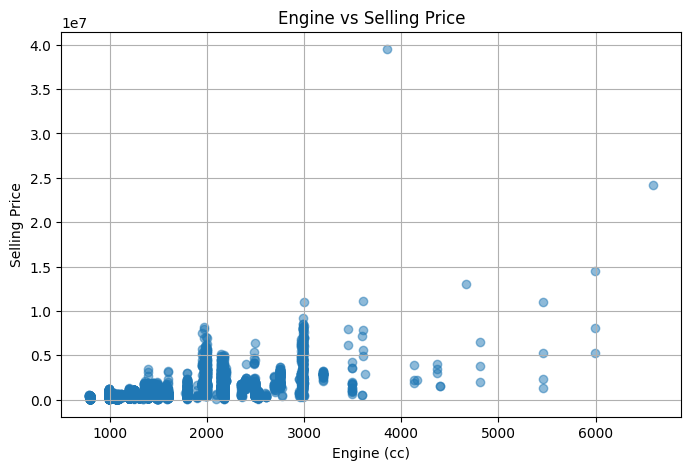

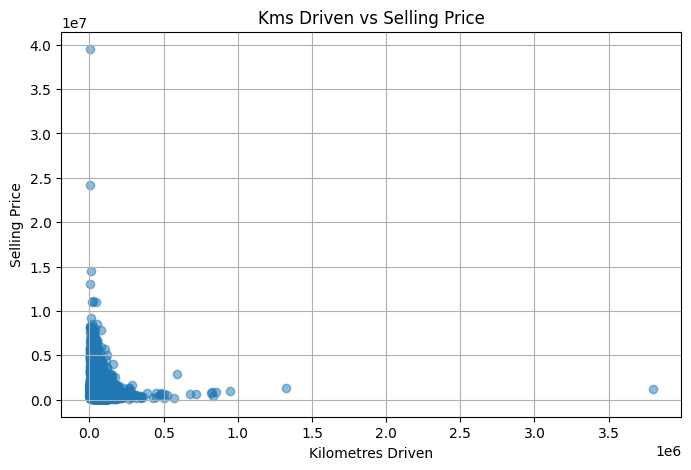

In [ ]:
# Engine vs Selling Price

plt.figure(figsize=(8, 5))

plt.scatter(
    model_df["engine"],
    model_df["selling_price"],
    alpha=0.5
)

plt.xlabel("Engine (cc)")
plt.ylabel("Selling Price")
plt.title("Engine vs Selling Price")
plt.grid(True)

plt.show()


# Kilometres Driven vs Selling Price

plt.figure(figsize=(8, 5))

plt.scatter(
    model_df["km_driven"],
    model_df["selling_price"],
    alpha=0.5
)

plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price")
plt.title("Kms Driven vs Selling Price")
plt.grid(True)

plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Numerical features to standardize

numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

feature_names = X_df.columns.tolist()

# Find the column positions
numerical_indices = [
    feature_names.index(feature)
    for feature in numerical_features
    if feature in feature_names
]

# Calculate mean and standard deviation using training data only
train_mean = np.mean(
    X_train[:, numerical_indices],
    axis=0
)

train_std = np.std(
    X_train[:, numerical_indices],
    axis=0
)

# Avoid division by zero
train_std[train_std == 0] = 1

# Standardize training data
X_train[:, numerical_indices] = (
    X_train[:, numerical_indices] - train_mean
) / train_std

# Standardize testing data using training statistics
X_test[:, numerical_indices] = (
    X_test[:, numerical_indices] - train_mean
) / train_std

print("Numerical features standardized:")
print(numerical_features)

print("\nTraining means:")
print(train_mean)

print("\nTraining standard deviations:")
print(train_std)

print("\nFirst five standardized training records:")
print(X_train[:5])

Numerical features standardized:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Training means:
[6.03244646e+00 5.56928196e+04 1.96915518e+01 1.48503739e+03
 1.00516747e+02 5.32624919e+00]

Training standard deviations:
[3.01874714e+00 5.44709544e+04 4.17263296e+00 5.18275963e+02
 4.27439546e+01 8.09570519e-01]

First five standardized training records:
[[ 1.97683120e+00  3.17732278e-01  1.60198190e-01 -5.55760666e-01
  -5.05726422e-01 -4.02990451e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00]
 [-6.73274828e-01  4.23561590e-02  1.84498573e+00 -4.57357492e-01
  -6.20362516e-01 -4.02990451e-01  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   1.00000000e+00]
 [ 3.20514932e-01  7.39975660e-01  2.58457492e-01 -4.57357492e-01
  -2.75050527e-01  2.06745524e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0

## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Separate features and target

X_df = model_df.drop(columns=["selling_price"])
y = model_df["selling_price"].values

# Convert features to NumPy array
X = X_df.values.astype(float)

# Fixed random seed
np.random.seed(42)

# Randomly shuffle indices
indices = np.random.permutation(len(X))

# Calculate 80% split
split_index = int(0.80 * len(X))

# Training and testing indices
train_indices = indices[:split_index]
test_indices = indices[split_index:]

# Create training and testing data
X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining percentage:",
      len(X_train) / len(X) * 100, "%")

print("Testing percentage:",
      len(X_test) / len(X) * 100, "%")

Training observations: 12328
Testing observations: 3083

Training percentage: 79.99480890273182 %
Testing percentage: 20.005191097268185 %


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
print("Training feature matrix shape:")
print(X_train.shape)

print("\nTraining target vector shape:")
print(y_train.shape)

print("\nTesting feature matrix shape:")
print(X_test.shape)

print("\nTesting target vector shape:")
print(y_test.shape)

print("\nNumber of predictor columns:")
print(X_train.shape[1])

Training feature matrix shape:
(12328, 13)

Training target vector shape:
(12328,)

Testing feature matrix shape:
(3083, 13)

Testing target vector shape:
(3083,)

Number of predictor columns:
13


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Add a column of ones for the intercept

X_train_bias = np.column_stack(
    (np.ones(X_train.shape[0]), X_train)
)

X_test_bias = np.column_stack(
    (np.ones(X_test.shape[0]), X_test)
)

print("Training matrix shape after adding bias:")
print(X_train_bias.shape)

print("\nTesting matrix shape after adding bias:")
print(X_test_bias.shape)

print("\nFirst five rows:")
print(X_train_bias[:5])

Training matrix shape after adding bias:
(12328, 14)

Testing matrix shape after adding bias:
(3083, 14)

First five rows:
[[ 1.00000000e+00  1.97683120e+00  3.17732278e-01  1.60198190e-01
  -5.55760666e-01 -5.05726422e-01 -4.02990451e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -6.73274828e-01  4.23561590e-02  1.84498573e+00
  -4.57357492e-01 -6.20362516e-01 -4.02990451e-01  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00  3.20514932e-01  7.39975660e-01  2.58457492e-01
  -4.57357492e-01 -2.75050527e-01  2.06745524e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -1.66706459e+00 -9.39818665e-01 -3.09529203e-01
   2.50110103e-02  4.40606231e-01 -4.02990451e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
def calculate_ols(X, y):
    """
    Calculate regression coefficients using
    the Ordinary Least Squares normal equation.
    """

    XT = X.T

    # Calculate X transpose X
    XT_X = XT @ X

    # Calculate X transpose y
    XT_y = XT @ y

    # Calculate regression coefficients
    beta = np.linalg.inv(XT_X) @ XT_y

    return beta


# Calculate regression coefficients
beta = calculate_ols(
    X_train_bias,
    y_train
)

print("Regression coefficient vector:")
print(beta)

Regression coefficient vector:
[ 994217.80724365 -195163.09053546  -34965.02601204   62397.2943623
   48021.81829649  644333.49945541    6812.17431665 -124692.42956252
  -96756.41053174  358735.63796481 -119859.21560938   -6783.55536347
  -78002.67281776 -121450.23037614]


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Calculate X transpose X

XT_X = X_train_bias.T @ X_train_bias

# Calculate determinant

determinant = np.linalg.det(XT_X)

print("Determinant of X^T X:")
print(determinant)

# Check singularity

if np.isclose(determinant, 0):
    print("\nThe matrix X^T X is singular or nearly singular.")
    print("Feature redundancy or multicollinearity should be investigated.")
else:
    print("\nThe matrix X^T X is non-singular.")
    print("The inverse can be calculated successfully.")

Determinant of X^T X:
4.028687647671399e+43

The matrix X^T X is non-singular.
The inverse can be calculated successfully.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Train the model using OLS

beta = calculate_ols(
    X_train_bias,
    y_train
)

print("Intercept (β0):")
print(beta[0])

print("\nRegression coefficients:")

for feature, coefficient in zip(X_df.columns, beta[1:]):
    print(
        f"{feature}: {coefficient:.6f}"
    )

Intercept (β0):
994217.8072436522

Regression coefficients:
vehicle_age: -195163.090535
km_driven: -34965.026012
mileage: 62397.294362
engine: 48021.818296
max_power: 644333.499455
seats: 6812.174317
fuel_type_Diesel: -124692.429563
fuel_type_Electric: -96756.410532
fuel_type_LPG: 358735.637965
fuel_type_Petrol: -119859.215609
seller_type_Individual: -6783.555363
seller_type_Trustmark Dealer: -78002.672818
transmission_type_Manual: -121450.230376


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
print("Interpretation of Regression Coefficients:\n")

for feature, coefficient in zip(X_df.columns, beta[1:]):

    if coefficient > 0:
        effect = "Positive"
        explanation = (
            "An increase in this feature tends to increase "
            "the predicted selling price."
        )
    elif coefficient < 0:
        effect = "Negative"
        explanation = (
            "An increase in this feature tends to decrease "
            "the predicted selling price."
        )
    else:
        effect = "Zero"
        explanation = (
            "This feature has almost no linear effect "
            "on the predicted selling price."
        )

    print(f"{feature}")
    print(f"Coefficient: {coefficient:.6f}")
    print(f"Effect: {effect}")
    print(f"Explanation: {explanation}")
    print("-" * 60)

Interpretation of Regression Coefficients:

vehicle_age
Coefficient: -195163.090535
Effect: Negative
Explanation: An increase in this feature tends to decrease the predicted selling price.
------------------------------------------------------------
km_driven
Coefficient: -34965.026012
Effect: Negative
Explanation: An increase in this feature tends to decrease the predicted selling price.
------------------------------------------------------------
mileage
Coefficient: 62397.294362
Effect: Positive
Explanation: An increase in this feature tends to increase the predicted selling price.
------------------------------------------------------------
engine
Coefficient: 48021.818296
Effect: Positive
Explanation: An increase in this feature tends to increase the predicted selling price.
------------------------------------------------------------
max_power
Coefficient: 644333.499455
Effect: Positive
Explanation: An increase in this feature tends to increase the predicted selling price.
------

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Predict selling prices

y_pred = X_test_bias @ beta

print("Actual vs Predicted Selling Prices:")

comparison = pd.DataFrame({
    "Actual Selling Price": y_test,
    "Predicted Selling Price": y_pred
})

display(comparison.head(10))

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000,2.046440e+06
1,1290000,1.431418e+06
2,485000,3.390972e+05
3,400000,5.432682e+05
4,800000,8.623530e+05
5,150000,-6.165112e+05
6,650000,8.209350e+05
7,325000,-1.758146e+05
8,300000,3.786409e+05
9,925000,7.769197e+05


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Calculate residuals

residuals = y_test - y_pred

# Calculate RSS

RSS = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nFirst 10 residuals:")
print(residuals[:10])

Residual Sum of Squares (RSS):
885105657669988.0

First 10 residuals:
[2403559.51403373 -141417.81281598  145902.81901473 -143268.1989145
  -62352.98172049  766511.22160147 -170934.99714305  500814.55130592
  -78640.91740412  148080.26893044]


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Calculate Total Sum of Squares

TSS = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

# Calculate R-squared

R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nResidual Sum of Squares (RSS):")
print(RSS)

print("\nR² Score:")
print(R2)

Total Sum of Squares (TSS):
2407385049859876.5

Residual Sum of Squares (RSS):
885105657669988.0

R² Score:
0.6323373123375066


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


Code 1 — Actual vs Predicted

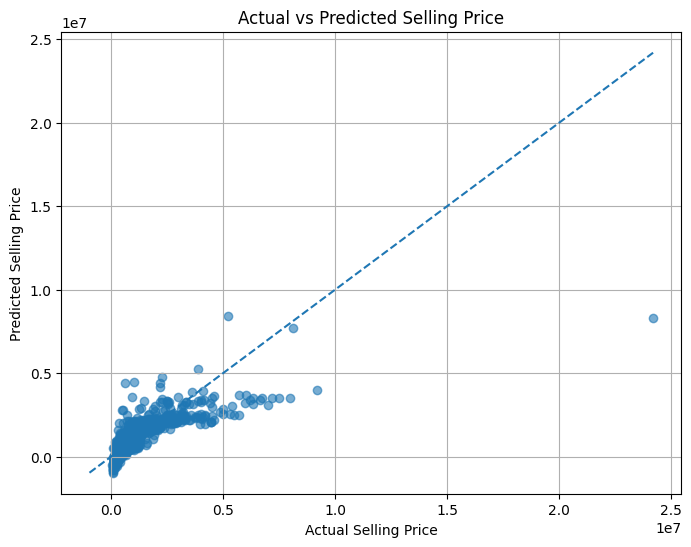

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.grid(True)
plt.show()

Code 2 — Residual Plot

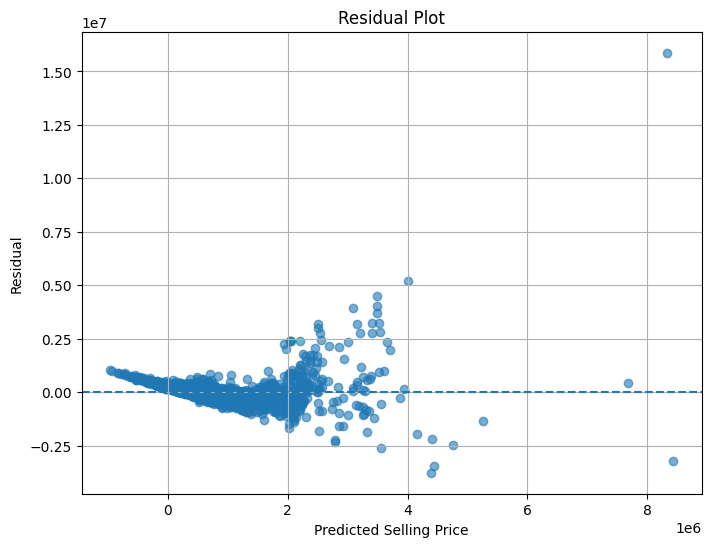

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid(True)
plt.show()

Code 3 — Find Large Prediction Errors

In [ ]:
# Calculate absolute errors

absolute_errors = np.abs(residuals)

# Get indices of five largest errors

largest_error_indices = np.argsort(
    absolute_errors
)[-5:]

print("Five observations with the largest prediction errors:\n")

for i in largest_error_indices:

    print(
        f"Actual Price = {y_test[i]:.2f}, "
        f"Predicted Price = {y_pred[i]:.2f}, "
        f"Residual = {residuals[i]:.2f}"
    )

Five observations with the largest prediction errors:

Actual Price = 7000000.00, Predicted Price = 3084722.09, Residual = 3915277.91
Actual Price = 7500000.00, Predicted Price = 3485713.74, Residual = 4014286.26
Actual Price = 8000000.00, Predicted Price = 3488916.56, Residual = 4511083.44
Actual Price = 9200000.00, Predicted Price = 4009019.39, Residual = 5190980.61
Actual Price = 24200000.00, Predicted Price = 8323205.42, Residual = 15876794.58


### Task 20: Conclude


The Multiple Linear Regression model was successfully implemented from scratch using the Ordinary Least Squares normal equation and NumPy matrix operations. The CarDekho used-car dataset was preprocessed by checking missing values, selecting meaningful features, converting categorical variables into dummy variables and standardizing numerical features.

The dataset was divided into training and testing sets using an 80:20 ratio. The OLS normal equation was used to calculate the regression coefficients, and these coefficients were then used to predict the selling prices of the test observations.

The model performance was evaluated using Residual Sum of Squares (RSS) and R². The obtained RSS value was [enter your Colab RSS value] and the obtained R² value was [enter your Colab R² value]. The regression coefficients helped identify the features having positive or negative influence on the predicted selling price.

The preprocessing and feature engineering steps made the data suitable for Multiple Linear Regression. However, used-car prices can depend on many factors and their relationships may not always be linear. Therefore, Multiple Linear Regression provides a useful basic prediction model, but its performance can be limited for complex real-world used-car price prediction.